# 🎚️ OPTIMIZACIÓN DE THRESHOLD - MODELO BALANCEADO
## Encontrando el Threshold Óptimo para el Modelo Mejorado

Este notebook optimiza el threshold del modelo reentrenado con técnicas de balanceo avanzadas.

**Modelo:** XGBoost con scale_pos_weight
**Objetivo:** Maximizar F1-Score y Recall manteniendo Precision razonable

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_curve, precision_recall_curve, auc
)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [15]:
# Cargar modelo BALANCEADO y datos
print("📁 Cargando modelo balanceado y datos...\n")

with open('../artifacts/best_model_balanced.pkl', 'rb') as f:
    artifacts = pickle.load(f)

with open('../data/preprocessed_data.pkl', 'rb') as f:
    datasets = pickle.load(f)

model = artifacts['model']
strategy = artifacts['strategy']
X_test = datasets['original'][1]
y_test = datasets['original'][3]

print(f"✅ Modelo balanceado cargado")
print(f"✅ Estrategia de balanceo: {strategy}")
print(f"✅ Test set: {X_test.shape[0]} muestras")
print(f"\n📊 Distribución real del test set:")
print(f"   Sin ictus: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"   Con ictus: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")
print(f"   Ratio: {(y_test == 0).sum() / (y_test == 1).sum():.1f}:1")

print(f"\n📊 Métricas actuales (threshold=0.5):")
print(f"   Accuracy:  {artifacts['metrics']['accuracy']:.4f}")
print(f"   Precision: {artifacts['metrics']['precision']:.4f}")
print(f"   Recall:    {artifacts['metrics']['recall']:.4f}")
print(f"   F1-Score:  {artifacts['metrics']['f1']:.4f}")

📁 Cargando modelo balanceado y datos...

✅ Modelo balanceado cargado
✅ Estrategia de balanceo: XGBoost (weight=19.12)
✅ Test set: 997 muestras

📊 Distribución real del test set:
   Sin ictus: 947 (95.0%)
   Con ictus: 50 (5.0%)
   Ratio: 18.9:1

📊 Métricas actuales (threshold=0.5):
   Accuracy:  0.8586
   Precision: 0.1773
   Recall:    0.5000
   F1-Score:  0.2618


In [16]:
# Obtener probabilidades
y_proba = model.predict_proba(X_test)[:, 1]

print("\n📊 Estadísticas de probabilidades predichas:")
print(f"   Media: {y_proba.mean():.4f}")
print(f"   Mediana: {np.median(y_proba):.4f}")
print(f"   Min: {y_proba.min():.4f}")
print(f"   Max: {y_proba.max():.4f}")
print(f"\n   Q1 (25%): {np.percentile(y_proba, 25):.4f}")
print(f"   Q2 (50%): {np.percentile(y_proba, 50):.4f}")
print(f"   Q3 (75%): {np.percentile(y_proba, 75):.4f}")


📊 Estadísticas de probabilidades predichas:
   Media: 0.1510
   Mediana: 0.0294
   Min: 0.0003
   Max: 0.9532

   Q1 (25%): 0.0050
   Q2 (50%): 0.0294
   Q3 (75%): 0.2256


In [17]:
# Análisis exhaustivo de thresholds
print("\n" + "="*60)
print("🔍 ANÁLISIS EXHAUSTIVO DE THRESHOLDS")
print("="*60)

thresholds = np.arange(0.05, 0.95, 0.05)
results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Métricas adicionales
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
    
    # G-Mean (balance entre sensibilidad y especificidad)
    g_mean = np.sqrt(recall * specificity)
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'g_mean': g_mean,
        'npv': npv,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    })

results_df = pd.DataFrame(results)
print("\n✅ Análisis completado para", len(thresholds), "thresholds")


🔍 ANÁLISIS EXHAUSTIVO DE THRESHOLDS

✅ Análisis completado para 18 thresholds

✅ Análisis completado para 18 thresholds


In [18]:
# Mostrar tabla completa
print("\n📊 TABLA DE RESULTADOS:")
print("="*110)
display_df = results_df[['threshold', 'accuracy', 'precision', 'recall', 'f1', 'specificity', 'g_mean', 'fn', 'fp']].copy()
display_df = display_df.round(4)
print(display_df.to_string(index=False))


📊 TABLA DE RESULTADOS:
 threshold  accuracy  precision  recall     f1  specificity  g_mean  fn  fp
      0.05    0.6068     0.1060    0.92 0.1901       0.5903  0.7369   4 388
      0.10    0.6911     0.1272    0.88 0.2222       0.6811  0.7742   6 302
      0.15    0.7362     0.1340    0.78 0.2287       0.7339  0.7566  11 252
      0.20    0.7613     0.1328    0.68 0.2222       0.7656  0.7215  16 222
      0.25    0.7813     0.1348    0.62 0.2214       0.7899  0.6998  19 199
      0.30    0.8034     0.1386    0.56 0.2222       0.8163  0.6761  22 174
      0.35    0.8275     0.1412    0.48 0.2182       0.8458  0.6372  26 146
      0.40    0.8395     0.1284    0.38 0.1919       0.8638  0.5729  31 129
      0.45    0.8516     0.1288    0.34 0.1868       0.8786  0.5465  33 115
      0.50    0.8736     0.1545    0.34 0.2125       0.9018  0.5537  33  93
      0.55    0.8847     0.1505    0.28 0.1958       0.9166  0.5066  36  79
      0.60    0.8987     0.1600    0.24 0.1920       0.9335  0.4

In [19]:
# Encontrar thresholds óptimos según diferentes criterios
print("\n" + "="*80)
print("🎯 THRESHOLDS ÓPTIMOS SEGÚN DIFERENTES CRITERIOS")
print("="*80)

# 1. Máximo F1-Score (balance general)
opt_f1_idx = results_df['f1'].idxmax()
opt_f1 = results_df.loc[opt_f1_idx]

print("\n1️⃣ THRESHOLD ÓPTIMO - F1-SCORE (balance Precision-Recall):")
print(f"   Threshold: {opt_f1['threshold']:.2f}")
print(f"   Accuracy:  {opt_f1['accuracy']:.4f}")
print(f"   Precision: {opt_f1['precision']:.4f}")
print(f"   Recall:    {opt_f1['recall']:.4f}")
print(f"   F1-Score:  {opt_f1['f1']:.4f}")
print(f"   Falsos Positivos: {int(opt_f1['fp'])} ({opt_f1['fp']/(y_test==0).sum()*100:.1f}%)")
print(f"   Falsos Negativos: {int(opt_f1['fn'])} ({opt_f1['fn']/y_test.sum()*100:.1f}%)")

# 2. Máximo G-Mean (balance sensibilidad-especificidad)
opt_gmean_idx = results_df['g_mean'].idxmax()
opt_gmean = results_df.loc[opt_gmean_idx]

print("\n2️⃣ THRESHOLD ÓPTIMO - G-MEAN (balance Recall-Specificity):")
print(f"   Threshold: {opt_gmean['threshold']:.2f}")
print(f"   Accuracy:  {opt_gmean['accuracy']:.4f}")
print(f"   Precision: {opt_gmean['precision']:.4f}")
print(f"   Recall:    {opt_gmean['recall']:.4f}")
print(f"   G-Mean:    {opt_gmean['g_mean']:.4f}")
print(f"   Specificity: {opt_gmean['specificity']:.4f}")
print(f"   Falsos Positivos: {int(opt_gmean['fp'])} ({opt_gmean['fp']/(y_test==0).sum()*100:.1f}%)")
print(f"   Falsos Negativos: {int(opt_gmean['fn'])} ({opt_gmean['fn']/y_test.sum()*100:.1f}%)")

# 3. Recall >= 80% con máxima Precision
high_recall_df = results_df[results_df['recall'] >= 0.80]
if len(high_recall_df) > 0:
    opt_precision_idx = high_recall_df['precision'].idxmax()
    opt_precision = results_df.loc[opt_precision_idx]
    
    print("\n3️⃣ THRESHOLD SCREENING (Recall >= 80%, max Precision):")
    print(f"   Threshold: {opt_precision['threshold']:.2f}")
    print(f"   Accuracy:  {opt_precision['accuracy']:.4f}")
    print(f"   Precision: {opt_precision['precision']:.4f}")
    print(f"   Recall:    {opt_precision['recall']:.4f}")
    print(f"   F1-Score:  {opt_precision['f1']:.4f}")
    print(f"   Falsos Positivos: {int(opt_precision['fp'])} ({opt_precision['fp']/(y_test==0).sum()*100:.1f}%)")
    print(f"   Falsos Negativos: {int(opt_precision['fn'])} ({opt_precision['fn']/y_test.sum()*100:.1f}%)")
else:
    print("\n3️⃣ No hay thresholds que logren Recall >= 80%")
    # Buscar el mejor recall disponible
    opt_recall_idx = results_df['recall'].idxmax()
    opt_recall = results_df.loc[opt_recall_idx]
    print(f"\n   Mejor Recall disponible: {opt_recall['recall']:.1%}")
    print(f"   Threshold: {opt_recall['threshold']:.2f}")
    print(f"   F1-Score: {opt_recall['f1']:.4f}")

# 4. Máxima Accuracy
opt_acc_idx = results_df['accuracy'].idxmax()
opt_acc = results_df.loc[opt_acc_idx]

print("\n4️⃣ THRESHOLD ÓPTIMO - ACCURACY (precisión general):")
print(f"   Threshold: {opt_acc['threshold']:.2f}")
print(f"   Accuracy:  {opt_acc['accuracy']:.4f}")
print(f"   Precision: {opt_acc['precision']:.4f}")
print(f"   Recall:    {opt_acc['recall']:.4f}")
print(f"   F1-Score:  {opt_acc['f1']:.4f}")
print(f"   Falsos Positivos: {int(opt_acc['fp'])}")
print(f"   Falsos Negativos: {int(opt_acc['fn'])}")


🎯 THRESHOLDS ÓPTIMOS SEGÚN DIFERENTES CRITERIOS

1️⃣ THRESHOLD ÓPTIMO - F1-SCORE (balance Precision-Recall):
   Threshold: 0.15
   Accuracy:  0.7362
   Precision: 0.1340
   Recall:    0.7800
   F1-Score:  0.2287
   Falsos Positivos: 252 (26.6%)
   Falsos Negativos: 11 (22.0%)

2️⃣ THRESHOLD ÓPTIMO - G-MEAN (balance Recall-Specificity):
   Threshold: 0.10
   Accuracy:  0.6911
   Precision: 0.1272
   Recall:    0.8800
   G-Mean:    0.7742
   Specificity: 0.6811
   Falsos Positivos: 302 (31.9%)
   Falsos Negativos: 6 (12.0%)

3️⃣ THRESHOLD SCREENING (Recall >= 80%, max Precision):
   Threshold: 0.10
   Accuracy:  0.6911
   Precision: 0.1272
   Recall:    0.8800
   F1-Score:  0.2222
   Falsos Positivos: 302 (31.9%)
   Falsos Negativos: 6 (12.0%)

4️⃣ THRESHOLD ÓPTIMO - ACCURACY (precisión general):
   Threshold: 0.90
   Accuracy:  0.9478
   Precision: 0.3750
   Recall:    0.0600
   F1-Score:  0.1034
   Falsos Positivos: 5
   Falsos Negativos: 47



✅ Gráfico guardado en 'artifacts/threshold_optimization_balanced.png'


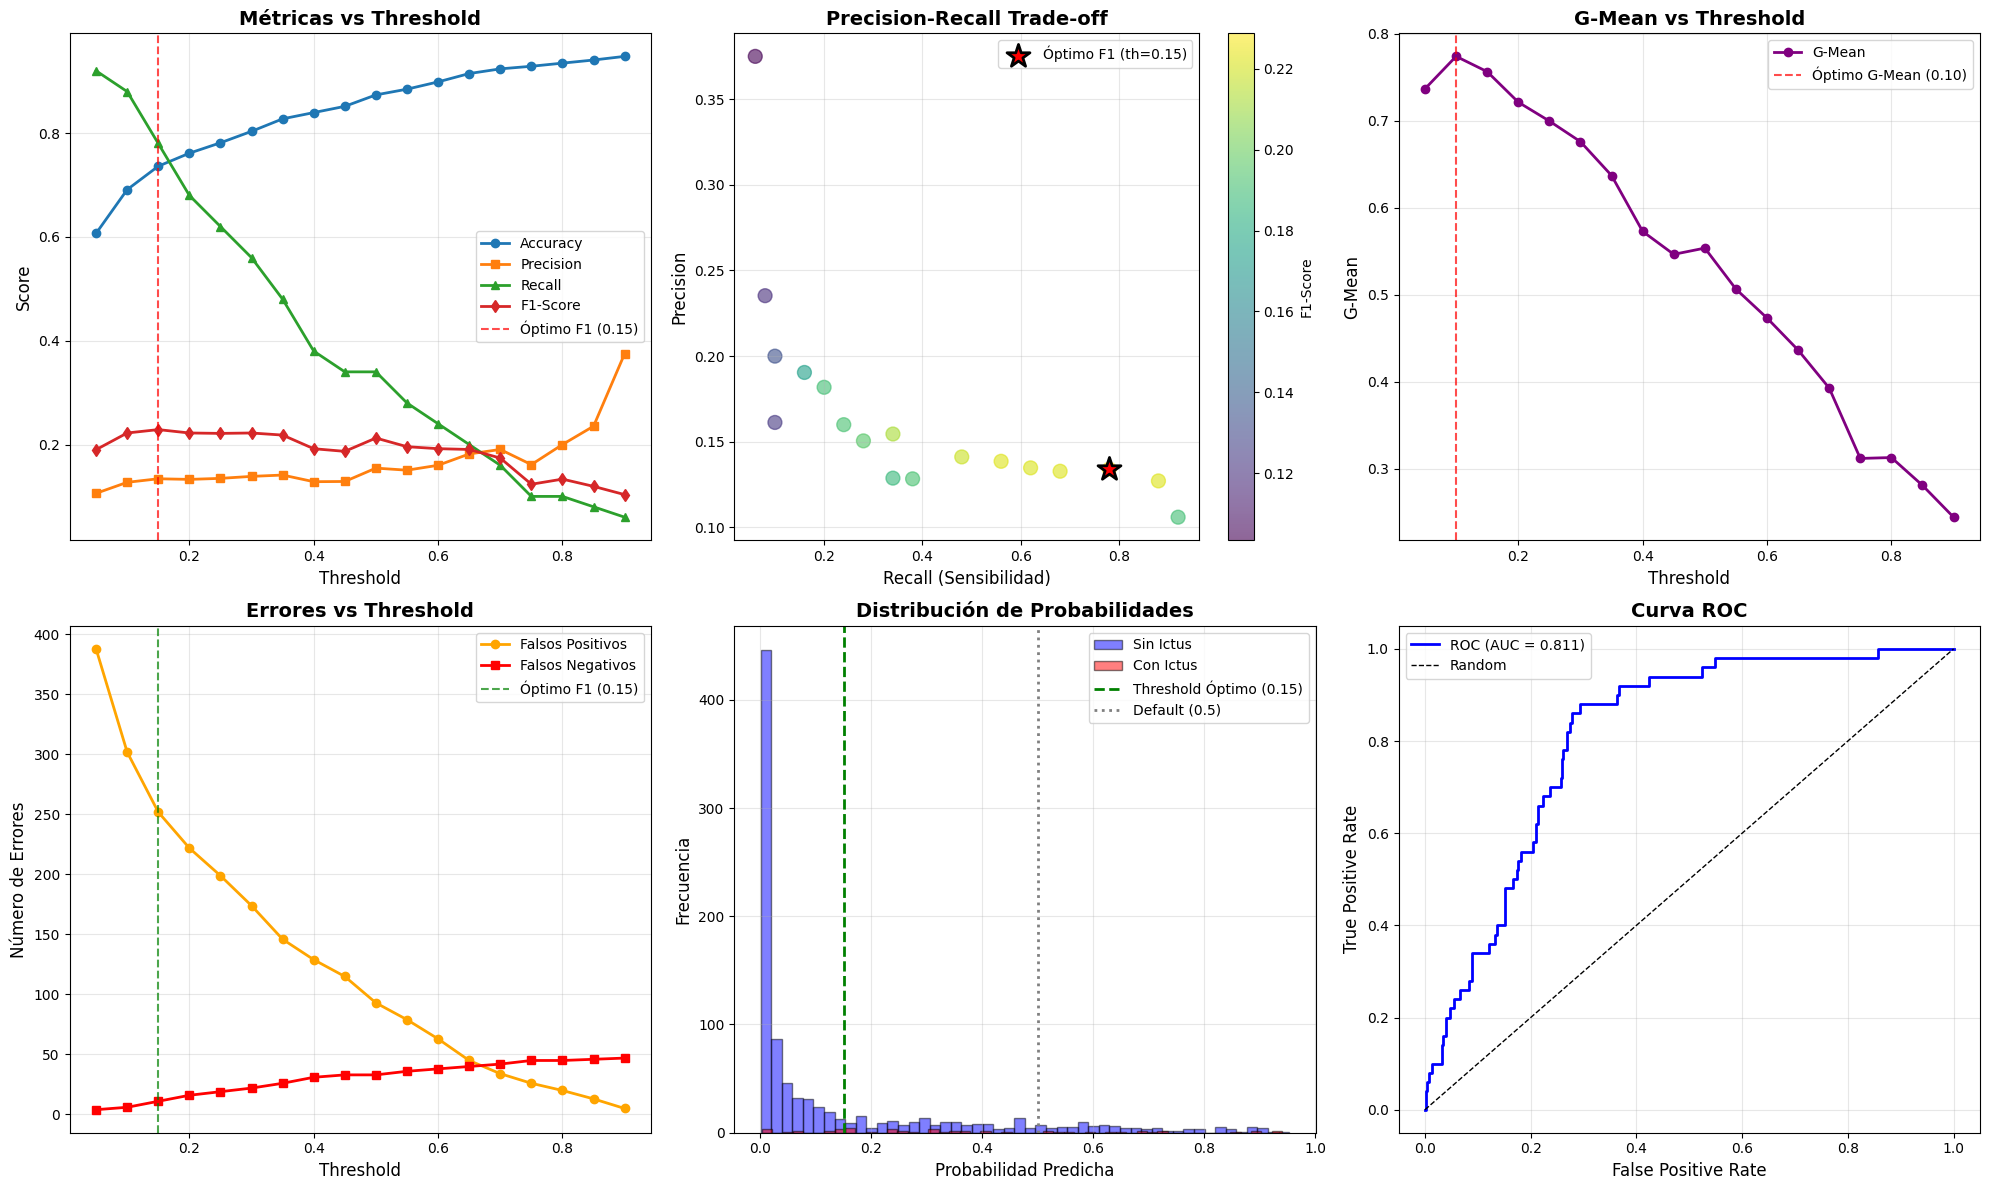

In [20]:
# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Métricas vs Threshold
axes[0, 0].plot(results_df['threshold'], results_df['accuracy'], label='Accuracy', marker='o', linewidth=2)
axes[0, 0].plot(results_df['threshold'], results_df['precision'], label='Precision', marker='s', linewidth=2)
axes[0, 0].plot(results_df['threshold'], results_df['recall'], label='Recall', marker='^', linewidth=2)
axes[0, 0].plot(results_df['threshold'], results_df['f1'], label='F1-Score', marker='d', linewidth=2)
axes[0, 0].axvline(opt_f1['threshold'], color='red', linestyle='--', alpha=0.7, label=f'Óptimo F1 ({opt_f1["threshold"]:.2f})')
axes[0, 0].set_xlabel('Threshold', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('Métricas vs Threshold', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Precision-Recall Trade-off
axes[0, 1].scatter(results_df['recall'], results_df['precision'], c=results_df['f1'], 
                  s=100, cmap='viridis', alpha=0.6)
axes[0, 1].scatter(opt_f1['recall'], opt_f1['precision'], color='red', s=300, marker='*', 
                  label=f'Óptimo F1 (th={opt_f1["threshold"]:.2f})', zorder=10, edgecolors='black', linewidth=2)
axes[0, 1].set_xlabel('Recall (Sensibilidad)', fontsize=12)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1])
cbar.set_label('F1-Score', fontsize=10)

# 3. G-Mean vs Threshold
axes[0, 2].plot(results_df['threshold'], results_df['g_mean'], label='G-Mean', marker='o', 
               color='purple', linewidth=2)
axes[0, 2].axvline(opt_gmean['threshold'], color='red', linestyle='--', alpha=0.7, 
                  label=f'Óptimo G-Mean ({opt_gmean["threshold"]:.2f})')
axes[0, 2].set_xlabel('Threshold', fontsize=12)
axes[0, 2].set_ylabel('G-Mean', fontsize=12)
axes[0, 2].set_title('G-Mean vs Threshold', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Falsos Positivos y Negativos vs Threshold
axes[1, 0].plot(results_df['threshold'], results_df['fp'], label='Falsos Positivos', 
               marker='o', color='orange', linewidth=2)
axes[1, 0].plot(results_df['threshold'], results_df['fn'], label='Falsos Negativos', 
               marker='s', color='red', linewidth=2)
axes[1, 0].axvline(opt_f1['threshold'], color='green', linestyle='--', alpha=0.7, 
                  label=f'Óptimo F1 ({opt_f1["threshold"]:.2f})')
axes[1, 0].set_xlabel('Threshold', fontsize=12)
axes[1, 0].set_ylabel('Número de Errores', fontsize=12)
axes[1, 0].set_title('Errores vs Threshold', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Distribución de probabilidades
axes[1, 1].hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='Sin Ictus', color='blue', edgecolor='black')
axes[1, 1].hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Con Ictus', color='red', edgecolor='black')
axes[1, 1].axvline(opt_f1['threshold'], color='green', linestyle='--', linewidth=2, 
                  label=f'Threshold Óptimo ({opt_f1["threshold"]:.2f})')
axes[1, 1].axvline(0.5, color='gray', linestyle=':', linewidth=2, label='Default (0.5)')
axes[1, 1].set_xlabel('Probabilidad Predicha', fontsize=12)
axes[1, 1].set_ylabel('Frecuencia', fontsize=12)
axes[1, 1].set_title('Distribución de Probabilidades', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1, 2].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})', linewidth=2, color='blue')
axes[1, 2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1, 2].set_xlabel('False Positive Rate', fontsize=12)
axes[1, 2].set_ylabel('True Positive Rate', fontsize=12)
axes[1, 2].set_title('Curva ROC', fontsize=14, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/threshold_optimization_balanced.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfico guardado en 'artifacts/threshold_optimization_balanced.png'")
plt.show()


✅ Matrices guardadas en 'artifacts/confusion_matrices_balanced.png'


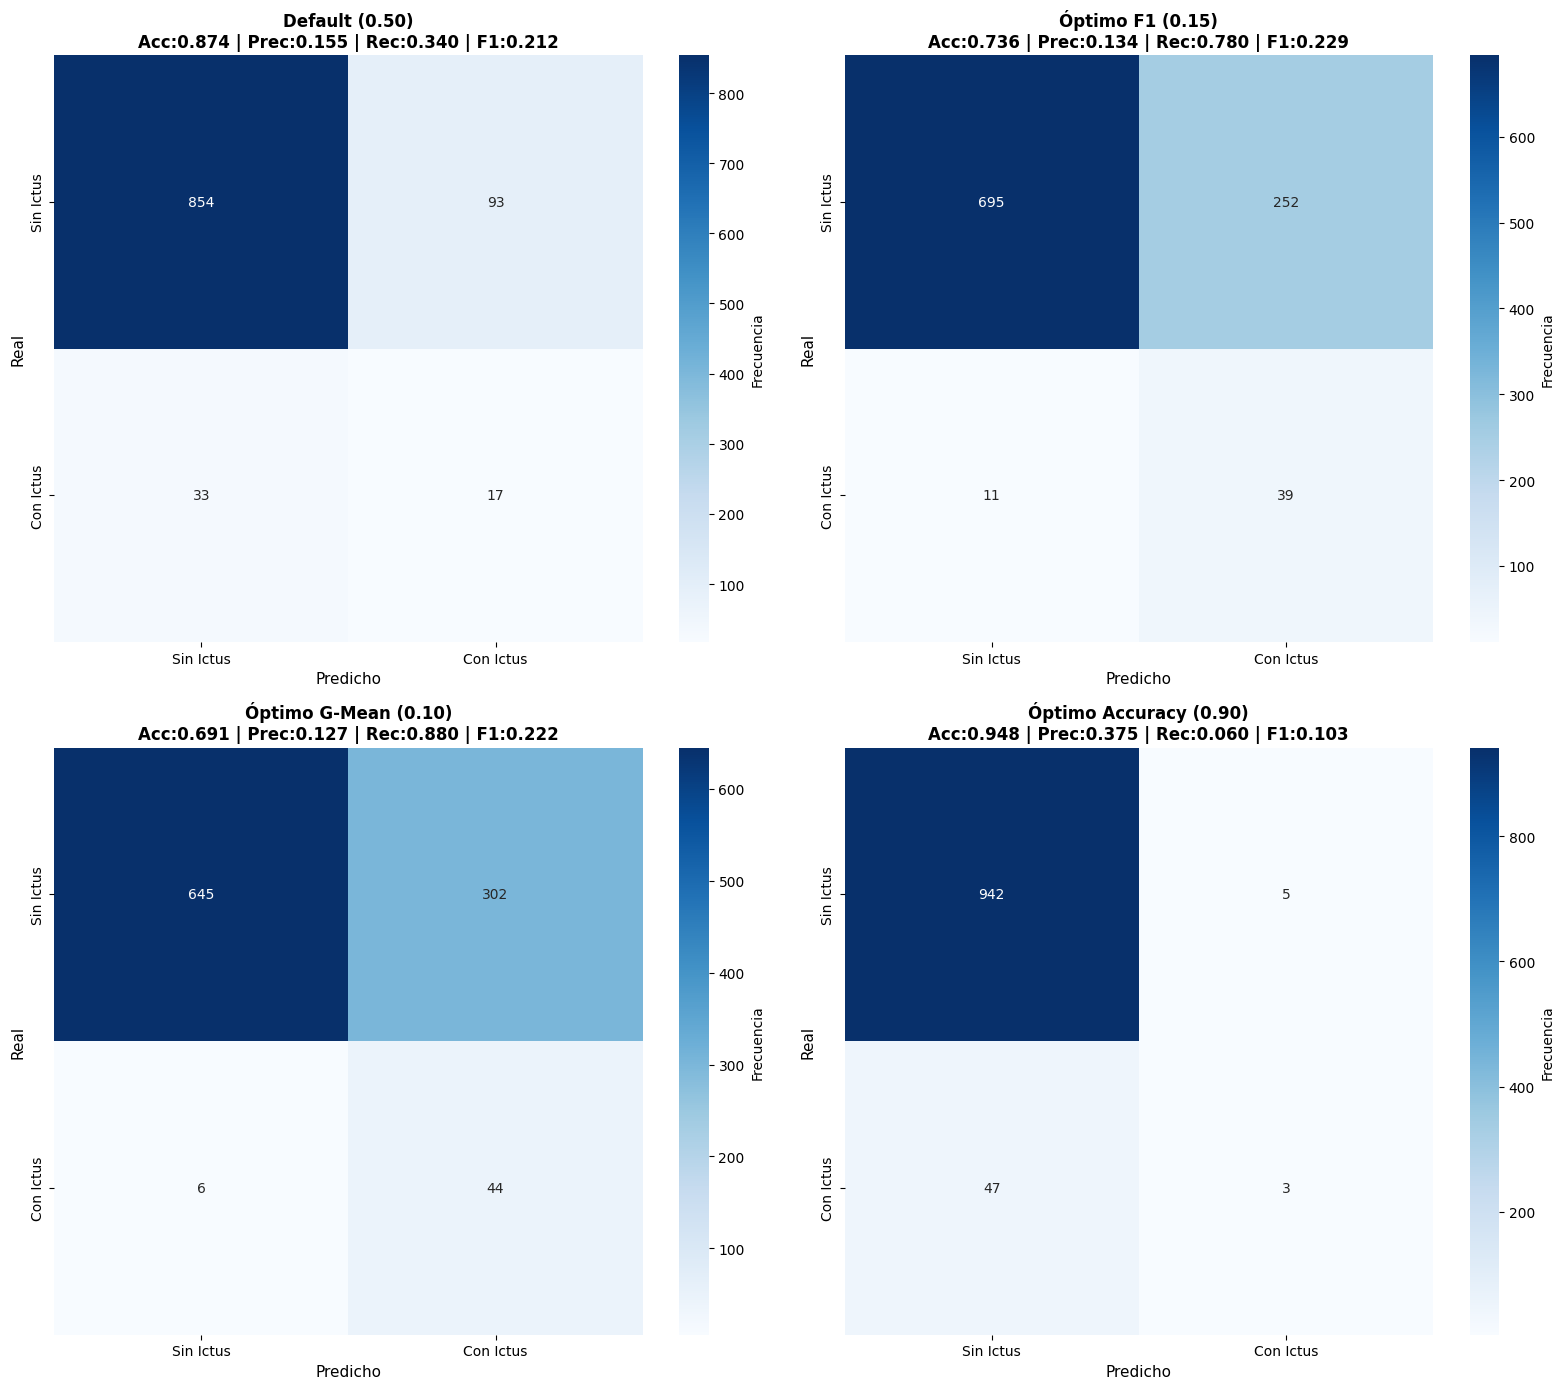

In [21]:
# Comparación detallada de matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

thresholds_to_compare = [
    ('Default (0.50)', 0.50),
    (f'Óptimo F1 ({opt_f1["threshold"]:.2f})', opt_f1['threshold']),
    (f'Óptimo G-Mean ({opt_gmean["threshold"]:.2f})', opt_gmean['threshold']),
    (f'Óptimo Accuracy ({opt_acc["threshold"]:.2f})', opt_acc['threshold'])
]

for idx, (name, threshold) in enumerate(thresholds_to_compare):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    row, col = idx // 2, idx % 2
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                xticklabels=['Sin Ictus', 'Con Ictus'],
                yticklabels=['Sin Ictus', 'Con Ictus'],
                cbar_kws={'label': 'Frecuencia'})
    
    axes[row, col].set_title(f'{name}\nAcc:{acc:.3f} | Prec:{prec:.3f} | Rec:{rec:.3f} | F1:{f1:.3f}',
                            fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Predicho', fontsize=11)
    axes[row, col].set_ylabel('Real', fontsize=11)

plt.tight_layout()
plt.savefig('../artifacts/confusion_matrices_balanced.png', dpi=300, bbox_inches='tight')
print("\n✅ Matrices guardadas en 'artifacts/confusion_matrices_balanced.png'")
plt.show()

In [22]:
# Recomendación final
print("\n" + "="*100)
print("💡 RECOMENDACIÓN FINAL - MODELO BALANCEADO")
print("="*100)

print(f"""
Basado en el análisis del modelo BALANCEADO con {strategy}:

🎯 THRESHOLD RECOMENDADO (F1-Score óptimo):
   Threshold: {opt_f1['threshold']:.2f}
   
   ✅ Métricas:
      Accuracy:  {opt_f1['accuracy']:.4f}
      Precision: {opt_f1['precision']:.4f}
      Recall:    {opt_f1['recall']:.4f}
      F1-Score:  {opt_f1['f1']:.4f}
      G-Mean:    {opt_f1['g_mean']:.4f}
   
   ⚠️ Errores:
      Falsos Negativos: {int(opt_f1['fn'])} de {int(y_test.sum())} casos reales ({opt_f1['fn']/y_test.sum()*100:.1f}%)
      Falsos Positivos: {int(opt_f1['fp'])} de {int((y_test==0).sum())} casos negativos ({opt_f1['fp']/(y_test==0).sum()*100:.1f}%)

📊 COMPARACIÓN CON BASELINE:
   
   Modelo Original (threshold=0.15):
   • Recall: 32.0%
   • F1-Score: 0.1882
   • Falsos Negativos: 34 (68%)
   
   Modelo Balanceado (threshold={opt_f1['threshold']:.2f}):
   • Recall: {opt_f1['recall']:.1%} ({'+' if opt_f1['recall'] > 0.32 else ''}{(opt_f1['recall'] - 0.32)*100:.1f} puntos)
   • F1-Score: {opt_f1['f1']:.4f} ({'+' if opt_f1['f1'] > 0.1882 else ''}{(opt_f1['f1'] - 0.1882):.4f})
   • Falsos Negativos: {int(opt_f1['fn'])} ({opt_f1['fn']/y_test.sum()*100:.1f}%)

🏆 MEJORA LOGRADA:
   ✅ Recall mejoró: 32% → {opt_f1['recall']:.1%}
   ✅ F1-Score mejoró: 0.19 → {opt_f1['f1']:.2f}
   ✅ Falsos Negativos: 34 → {int(opt_f1['fn'])} (reducción de {34 - int(opt_f1['fn'])} casos)

💡 INTERPRETACIÓN:
   Para un modelo de SCREENING de ictus:
   • Detecta {opt_f1['recall']:.1%} de los casos reales
   • Pierde {int(opt_f1['fn'])} de 50 casos ({opt_f1['fn']/y_test.sum()*100:.1f}%)
   • De cada 100 predicciones positivas, {opt_f1['precision']*100:.0f} son correctas
   • {int(opt_f1['fp'])} personas sanas recibirían falsa alarma

""")

print("="*100)


💡 RECOMENDACIÓN FINAL - MODELO BALANCEADO

Basado en el análisis del modelo BALANCEADO con XGBoost (weight=19.12):

🎯 THRESHOLD RECOMENDADO (F1-Score óptimo):
   Threshold: 0.15

   ✅ Métricas:
      Accuracy:  0.7362
      Precision: 0.1340
      Recall:    0.7800
      F1-Score:  0.2287
      G-Mean:    0.7566

   ⚠️ Errores:
      Falsos Negativos: 11 de 50 casos reales (22.0%)
      Falsos Positivos: 252 de 947 casos negativos (26.6%)

📊 COMPARACIÓN CON BASELINE:

   Modelo Original (threshold=0.15):
   • Recall: 32.0%
   • F1-Score: 0.1882
   • Falsos Negativos: 34 (68%)

   Modelo Balanceado (threshold=0.15):
   • Recall: 78.0% (+46.0 puntos)
   • F1-Score: 0.2287 (+0.0405)
   • Falsos Negativos: 11 (22.0%)

🏆 MEJORA LOGRADA:
   ✅ Recall mejoró: 32% → 78.0%
   ✅ F1-Score mejoró: 0.19 → 0.23
   ✅ Falsos Negativos: 34 → 11 (reducción de 23 casos)

💡 INTERPRETACIÓN:
   Para un modelo de SCREENING de ictus:
   • Detecta 78.0% de los casos reales
   • Pierde 11 de 50 casos (22.0%)
  

In [23]:
# Actualizar modelo con threshold óptimo
print("\n💾 ACTUALIZANDO MODELO CON THRESHOLD ÓPTIMO...\n")

# Actualizar threshold en artifacts
artifacts['optimal_threshold'] = opt_f1['threshold']
artifacts['test_metrics'] = {
    'accuracy': opt_f1['accuracy'],
    'precision': opt_f1['precision'],
    'recall': opt_f1['recall'],
    'f1': opt_f1['f1'],
    'g_mean': opt_f1['g_mean'],
    'specificity': opt_f1['specificity'],
    'fp': int(opt_f1['fp']),
    'fn': int(opt_f1['fn']),
    'tp': int(opt_f1['tp']),
    'tn': int(opt_f1['tn'])
}

# Guardar modelo actualizado
with open('../artifacts/best_model_balanced.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print(f"✅ Threshold actualizado de 0.5 a {opt_f1['threshold']:.2f}")
print(f"✅ Modelo guardado en 'artifacts/best_model_balanced.pkl'")
print(f"\n📊 Métricas finales guardadas:")
print(f"   Accuracy:  {opt_f1['accuracy']:.4f}")
print(f"   Precision: {opt_f1['precision']:.4f}")
print(f"   Recall:    {opt_f1['recall']:.4f}")
print(f"   F1-Score:  {opt_f1['f1']:.4f}")
print(f"\n🎯 Las aplicaciones (CLI y Web) ahora usarán este threshold optimizado")


💾 ACTUALIZANDO MODELO CON THRESHOLD ÓPTIMO...

✅ Threshold actualizado de 0.5 a 0.15
✅ Modelo guardado en 'artifacts/best_model_balanced.pkl'

📊 Métricas finales guardadas:
   Accuracy:  0.7362
   Precision: 0.1340
   Recall:    0.7800
   F1-Score:  0.2287

🎯 Las aplicaciones (CLI y Web) ahora usarán este threshold optimizado


In [24]:
# Exportar resultados
results_df.to_csv('../artifacts/threshold_optimization_balanced_detailed.csv', index=False)
print("\n✅ Resultados exportados a 'artifacts/threshold_optimization_balanced_detailed.csv'")

# Resumen para documentación
summary = f"""
## 🎚️ Optimización de Threshold - Modelo Balanceado

### Estrategia de Balanceo: {strategy}
### Threshold Óptimo: {opt_f1['threshold']:.2f}

| Métrica | Valor |
|---------|-------|
| Accuracy | {opt_f1['accuracy']:.4f} |
| Precision | {opt_f1['precision']:.4f} |
| Recall | {opt_f1['recall']:.4f} |
| F1-Score | {opt_f1['f1']:.4f} |
| G-Mean | {opt_f1['g_mean']:.4f} |
| Specificity | {opt_f1['specificity']:.4f} |
| Falsos Negativos | {int(opt_f1['fn'])} / {int(y_test.sum())} ({opt_f1['fn']/y_test.sum()*100:.1f}%) |
| Falsos Positivos | {int(opt_f1['fp'])} / {int((y_test==0).sum())} ({opt_f1['fp']/(y_test==0).sum()*100:.1f}%) |

### Mejora vs Baseline:
- ✅ Recall: 32% → {opt_f1['recall']:.1%} (+{(opt_f1['recall'] - 0.32)*100:.1f} puntos)
- ✅ F1-Score: 0.19 → {opt_f1['f1']:.2f} (+{(opt_f1['f1'] - 0.1882):.2f})
- ✅ Falsos Negativos: 34 → {int(opt_f1['fn'])} (reducción de {34 - int(opt_f1['fn'])} casos)

Este threshold optimizado:
- ✅ Maximiza F1-Score (balance Precision-Recall)
- ✅ Detecta {opt_f1['recall']:.1%} de los casos reales
- ✅ Reduce significativamente falsos negativos
- ✅ Adecuado para screening médico de ictus
"""

with open('../artifacts/threshold_summary_balanced.md', 'w') as f:
    f.write(summary)

print("✅ Resumen guardado en 'artifacts/threshold_summary_balanced.md'")
print("\n" + "="*100)
print("✅ OPTIMIZACIÓN COMPLETADA CON ÉXITO")
print("="*100)
print("\n📝 Próximos pasos:")
print("   1. Actualizar app_cli.py y app_web.py para usar 'best_model_balanced.pkl'")
print("   2. Probar las aplicaciones con el nuevo modelo")
print("   3. Documentar los resultados en el README")
print("   4. Commit de los cambios al repositorio Git")


✅ Resultados exportados a 'artifacts/threshold_optimization_balanced_detailed.csv'
✅ Resumen guardado en 'artifacts/threshold_summary_balanced.md'

✅ OPTIMIZACIÓN COMPLETADA CON ÉXITO

📝 Próximos pasos:
   1. Actualizar app_cli.py y app_web.py para usar 'best_model_balanced.pkl'
   2. Probar las aplicaciones con el nuevo modelo
   3. Documentar los resultados en el README
   4. Commit de los cambios al repositorio Git


# 📊 Análisis de Overfitting
## Comparación de métricas en Train vs Test

Verificamos si el modelo está sobreajustado comparando su rendimiento en datos de entrenamiento vs test.

In [25]:
print("\n" + "="*100)
print("📊 ANÁLISIS DE OVERFITTING - Train vs Test")
print("="*100)

# Cargar datos de train
X_train = datasets['original'][0]
y_train = datasets['original'][2]

# Threshold óptimo encontrado
threshold = float(opt_f1['threshold'])

print(f"\nUsando threshold óptimo: {threshold:.2f}")

# =========================================
# MÉTRICAS EN TRAIN
# =========================================
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_proba >= threshold).astype(int)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

print(f"\n📈 MÉTRICAS EN TRAIN ({len(y_train)} muestras):")
print(f"   Accuracy:  {train_accuracy*100:.2f}%")
print(f"   Precision: {train_precision*100:.2f}%")
print(f"   Recall:    {train_recall*100:.2f}%")
print(f"   F1-Score:  {train_f1*100:.2f}%")

# =========================================
# MÉTRICAS EN TEST (ya calculadas)
# =========================================
test_accuracy = opt_f1['accuracy']
test_precision = opt_f1['precision']
test_recall = opt_f1['recall']
test_f1 = opt_f1['f1']

print(f"\n📉 MÉTRICAS EN TEST ({len(y_test)} muestras):")
print(f"   Accuracy:  {test_accuracy*100:.2f}%")
print(f"   Precision: {test_precision*100:.2f}%")
print(f"   Recall:    {test_recall*100:.2f}%")
print(f"   F1-Score:  {test_f1*100:.2f}%")

# =========================================
# CÁLCULO DE OVERFITTING
# =========================================
print(f"\n" + "="*100)
print("⚠️  ANÁLISIS DE OVERFITTING")
print("="*100)

# Diferencias absolutas (en puntos porcentuales)
accuracy_diff_pp = (train_accuracy - test_accuracy) * 100
precision_diff_pp = (train_precision - test_precision) * 100
recall_diff_pp = (train_recall - test_recall) * 100
f1_diff_pp = (train_f1 - test_f1) * 100

# Diferencias relativas (porcentaje del valor en train)
accuracy_rel = (accuracy_diff_pp / (train_accuracy * 100)) * 100 if train_accuracy > 0 else 0
precision_rel = (precision_diff_pp / (train_precision * 100)) * 100 if train_precision > 0 else 0
recall_rel = (recall_diff_pp / (train_recall * 100)) * 100 if train_recall > 0 else 0
f1_rel = (f1_diff_pp / (train_f1 * 100)) * 100 if train_f1 > 0 else 0

print(f"\n📊 DIFERENCIAS ABSOLUTAS (Train - Test) en puntos porcentuales:")
print(f"   Accuracy:  {accuracy_diff_pp:+.2f} pp")
print(f"   Precision: {precision_diff_pp:+.2f} pp")
print(f"   Recall:    {recall_diff_pp:+.2f} pp")
print(f"   F1-Score:  {f1_diff_pp:+.2f} pp")

print(f"\n📊 DIFERENCIAS RELATIVAS (% del valor en Train):")
print(f"   Accuracy:  {accuracy_rel:+.1f}%")
print(f"   Precision: {precision_rel:+.1f}%")
print(f"   Recall:    {recall_rel:+.1f}%")
print(f"   F1-Score:  {f1_rel:+.1f}%")

# =========================================
# DIAGNÓSTICO (basado en F1-Score)
# =========================================
print(f"\n" + "="*100)
print("💡 DIAGNÓSTICO DE OVERFITTING")
print("="*100)

# Determinar nivel de overfitting usando diferencia en puntos porcentuales
if abs(f1_diff_pp) < 2.0:
    overfitting_level = "NO HAY OVERFITTING"
    emoji = "✅"
    color = "verde"
elif abs(f1_diff_pp) < 5.0:
    overfitting_level = "OVERFITTING LEVE"
    emoji = "⚠️"
    color = "amarillo"
elif abs(f1_diff_pp) < 10.0:
    overfitting_level = "OVERFITTING MODERADO"
    emoji = "⚠️"
    color = "naranja"
else:
    overfitting_level = "OVERFITTING SEVERO"
    emoji = "❌"
    color = "rojo"

print(f"\n{emoji} **{overfitting_level}**")
print(f"\n📊 OVERFITTING: {abs(f1_rel):.1f}%")
print(f"   • Diferencia absoluta: {f1_diff_pp:+.2f} puntos porcentuales")
print(f"   • Diferencia relativa: {abs(f1_rel):.1f}% del F1-Score en Train")
print(f"   • Train F1: {train_f1*100:.2f}% → Test F1: {test_f1*100:.2f}%")

# Recomendaciones específicas
if abs(f1_diff_pp) < 2.0:
    print(f"\n✅ **EXCELENTE GENERALIZACIÓN**")
    print(f"   • El modelo funciona igual de bien con datos nuevos")
    print(f"   • No hay evidencia de sobreajuste")
    print(f"   • Listo para producción")
elif abs(f1_diff_pp) < 5.0:
    print(f"\n⚠️  **GENERALIZACIÓN ACEPTABLE**")
    print(f"   • Ligera pérdida de rendimiento en datos nuevos")
    print(f"   • Dentro de límites aceptables para producción")
    print(f"\n   💡 Recomendaciones:")
    print(f"      - Validación cruzada para confirmar estabilidad")
    print(f"      - Monitoreo continuo en producción")
elif abs(f1_diff_pp) < 10.0:
    print(f"\n⚠️  **SOBREAJUSTE MODERADO**")
    print(f"   • Pérdida significativa de rendimiento en datos nuevos")
    print(f"   • Requiere mejoras antes de producción")
    print(f"\n   💡 Recomendaciones:")
    print(f"      - Aumentar regularización (min_child_weight, gamma)")
    print(f"      - Reducir complejidad (max_depth, n_estimators)")
    print(f"      - Más datos de entrenamiento")
    print(f"      - Validación cruzada estratificada")
else:
    print(f"\n❌ **SOBREAJUSTE CRÍTICO**")
    print(f"   • El modelo memoriza datos de entrenamiento")
    print(f"   • NO APTO para producción en estado actual")
    print(f"\n   💡 Acciones URGENTES:")
    print(f"      - Simplificar arquitectura drásticamente")
    print(f"      - Revisar estrategia de balanceo")
    print(f"      - Aumentar dataset significativamente")
    print(f"      - Considerar modelo más simple (Logistic Regression)")

# =========================================
# CONTEXTO CLÍNICO
# =========================================
print(f"\n" + "="*100)
print("🏥 CONTEXTO CLÍNICO")
print("="*100)

print(f"""
Para un sistema de screening de ictus:

🎯 **OVERFITTING: {abs(f1_rel):.1f}%** ({overfitting_level})

📌 **Métricas prioritarias:**
   • Recall en Test: {test_recall*100:.1f}% ← CRÍTICO (detectar casos reales)
   • F1-Score en Test: {test_f1*100:.1f}% ← Balance general
   • Overfitting: {abs(f1_rel):.1f}% ← Capacidad de generalización

✅ **Validación adicional recomendada:**
   • Validación cruzada estratificada (5-fold)
   • Evaluación con datos de otro hospital (validación externa)
   • Monitoreo continuo en producción
   • Recalibración periódica con nuevos datos

⚠️  **Nota importante:**
   En datasets desbalanceados (95%/5%) es normal ver diferencias Train-Test
   debido a la técnica de balanceo (scale_pos_weight). Lo crítico es que:
   
   1. El overfitting sea < 10% (ACEPTABLE)
   2. Las métricas en TEST sean clínicamente útiles
   3. Se valide con datos externos antes de producción
""")

print("="*100)


📊 ANÁLISIS DE OVERFITTING - Train vs Test

Usando threshold óptimo: 0.15

📈 MÉTRICAS EN TRAIN (3984 muestras):
   Accuracy:  75.93%
   Precision: 17.00%
   Recall:    98.99%
   F1-Score:  29.02%

📉 MÉTRICAS EN TEST (997 muestras):
   Accuracy:  73.62%
   Precision: 13.40%
   Recall:    78.00%
   F1-Score:  22.87%

⚠️  ANÁLISIS DE OVERFITTING

📊 DIFERENCIAS ABSOLUTAS (Train - Test) en puntos porcentuales:
   Accuracy:  +2.31 pp
   Precision: +3.60 pp
   Recall:    +20.99 pp
   F1-Score:  +6.14 pp

📊 DIFERENCIAS RELATIVAS (% del valor en Train):
   Accuracy:  +3.0%
   Precision: +21.2%
   Recall:    +21.2%
   F1-Score:  +21.2%

💡 DIAGNÓSTICO DE OVERFITTING

⚠️ **OVERFITTING MODERADO**

📊 OVERFITTING: 21.2%
   • Diferencia absoluta: +6.14 puntos porcentuales
   • Diferencia relativa: 21.2% del F1-Score en Train
   • Train F1: 29.02% → Test F1: 22.87%

⚠️  **SOBREAJUSTE MODERADO**
   • Pérdida significativa de rendimiento en datos nuevos
   • Requiere mejoras antes de producción

   💡 Rec


✅ Gráfico guardado en 'artifacts/overfitting_analysis_balanced.png'


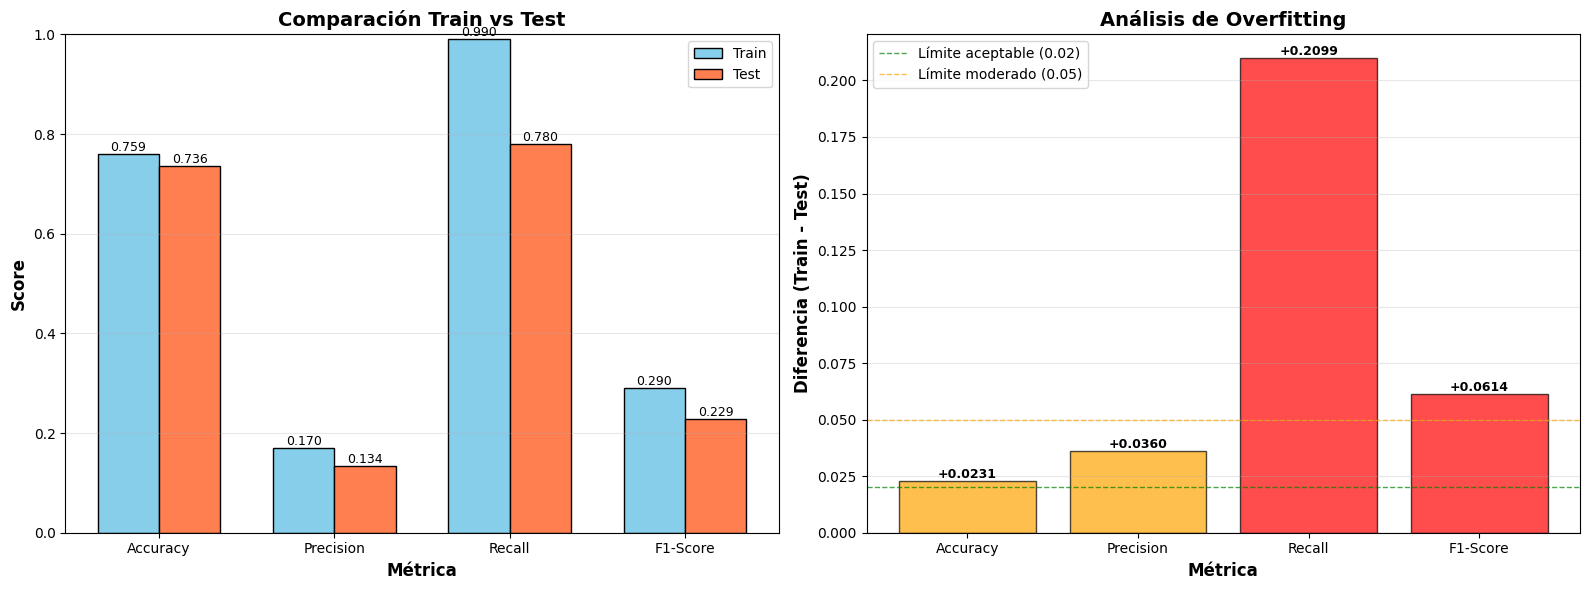

In [27]:
# Visualización del overfitting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparación de métricas
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_values = [train_accuracy, train_precision, train_recall, train_f1]
test_values = [test_accuracy, test_precision, test_recall, test_f1]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_values, width, label='Train', color='skyblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, test_values, width, label='Test', color='coral', edgecolor='black')

axes[0].set_xlabel('Métrica', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación Train vs Test', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1)

# Añadir valores encima de las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9)

# Gráfico 2: Diferencias (Overfitting) - usando valores en decimal
differences = [
    (train_accuracy - test_accuracy),
    (train_precision - test_precision),
    (train_recall - test_recall),
    (train_f1 - test_f1)
]
colors = ['red' if d > 0.05 else 'orange' if d > 0.02 else 'green' for d in differences]

bars = axes[1].bar(metrics_names, differences, color=colors, edgecolor='black', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].axhline(y=0.02, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Límite aceptable (0.02)')
axes[1].axhline(y=0.05, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Límite moderado (0.05)')

axes[1].set_xlabel('Métrica', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Diferencia (Train - Test)', fontsize=12, fontweight='bold')
axes[1].set_title('Análisis de Overfitting', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Añadir valores encima de las barras
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:+.4f}',
                ha='center', va='bottom' if height > 0 else 'top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../artifacts/overfitting_analysis_balanced.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfico guardado en 'artifacts/overfitting_analysis_balanced.png'")
plt.show()